<a href="https://colab.research.google.com/github/Vladimir202310/VSE/blob/Task_02/Task_02/task_02_visualizations/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%222_%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8_%D0%B2_Python_(adv)%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 2. Библиотеки для визуализаций в Python

Задание выполнил(а):

    Исаев Владимир

## Общая информация

__Внимание!__  

Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов. Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов.

Каждое задание весит 0.5 или 1 балл (указано рядом с номером задания). Всего в сумме можно получить, если правильно решить все задания, 10 баллов.

## Раздел 1. Визуализации в датасете кредитного скоринга

### О задании

Вы будете работать с задачей кредитного скоринга (оценка надёжности клиента). Предоставляются данные о 1000 клиентов, про которых известно около 20 признаков и положительная или отрицательная оценка в качестве кредитуемого. Эти данные нужно исследовать с помощью средств визуализации.

*Описание данных*:
https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Каждый построенный график необходимо красиво оформить – для этого требуется как минимум указать его название, а также отметить, что изображено по каждой из осей.
Также по каждому графику ожидается небольшой комментарий с выводами.

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
GERMAN_CREDIT = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'

### Задание 1 (0.5 балла)

Используя `numpy` и `matplotlib`, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ на интервале от $-\pi$ до $\pi$, используя 100 точек. Добавьте легенду и сетку.. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться примерно как на картинке. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

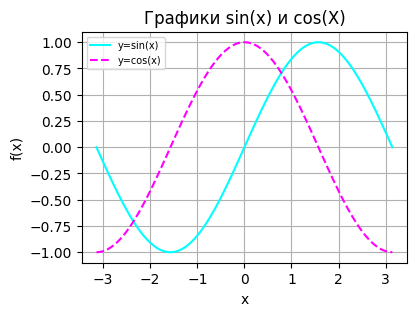

In [3]:
# ваш код здесь

fig = plt.figure(figsize=(4.2, 3))
ax = plt.axes()
plt.yticks(np.arange(-1, 1.1, 0.25))
plt.grid()
plt.title('Графики sin(x) и cos(X)')
plt.xlabel('x')
plt.ylabel('f(x)')


x = np.linspace(-np.pi, np.pi, 100)
ax.plot(x, np.sin(x), color='cyan')


ax.plot(x, np.cos(x), ls='--',color='magenta')


ax.legend(loc='upper left', labels=['y=sin(x)', 'y=cos(x)'], fontsize = 7);

In [56]:
# то что должно получиться

### Задание 2 (0.5 балла)

Прочитайте средствами pandas файл с данными кредитного скоринга. Рассмотрите сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

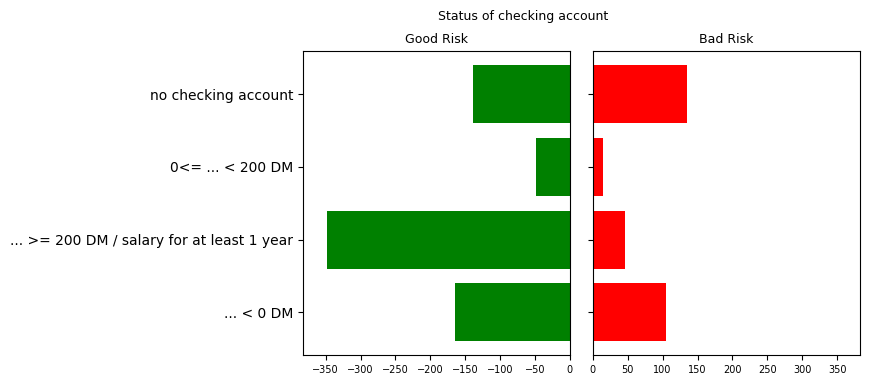

In [5]:
# ваш код здесь
url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

status_col = 'status'
target_col = 'credit_risk'

# 1. Считаем, сколько good / bad для каждого статуса
counts = (
    df
    .groupby([status_col, target_col])
    .size()
    .unstack(fill_value=0)    # столбцы 'good' и 'bad'
    .reset_index()
)

# Переименуем под график
counts = counts.rename(columns={
    status_col: 'Status',
    'good': 'Good Risk',
    'bad': 'Bad Risk'
})

# 2. Готовим данные для «двусторонней» гистограммы
counts['Good_neg'] = -counts['Good Risk']

y = counts['Status']
good = counts['Good_neg']
bad = counts['Bad Risk']

fig, (ax_left, ax_right) = plt.subplots(
    ncols=2, sharey=True, figsize=(8.8, 4)
)

plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7

#чтобы левая и правая часть были пропорциональны нам необходимо устновить равные диапазоны. Их размер по модулю определяется максимуму модулей среди среди минимальтного и максимального значения
limit = max(abs(min(good)), abs(max(bad)))


# Левая часть — Good Risk
ax_left.barh(y, good, color='green')
ax_left.set_title('Good Risk', fontsize=9)
ax_left.set_xlim(-limit * 1.1, 0)
ax_left.tick_params(axis='x', labelsize=7)

# Правая часть — Bad Risk
ax_right.barh(y, bad, color='red')
ax_right.set_title('Bad Risk', fontsize=9)
ax_right.set_xlim(0, limit * 1.1)
ax_right.tick_params(axis='x', labelsize=7)

fig.suptitle('Status of checking account', y=0.95, x=0.6, fontsize=9)
plt.tight_layout()
plt.show()


In [6]:
# то что должно получиться

### Задание 3  (0.5 балла)

In [7]:
import seaborn as sns

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

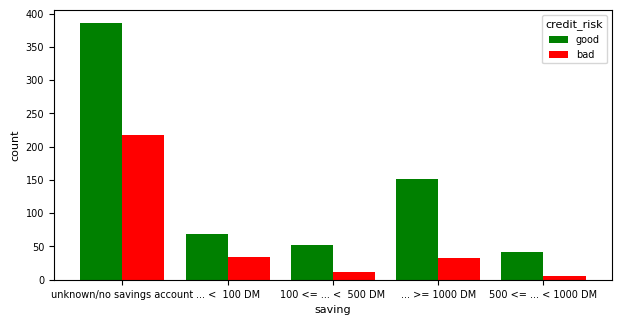

In [8]:
# ваш код здесь
url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)


# сгруппировать и посчитать количества
counts = (
    df.groupby(['savings', 'credit_risk'],sort=False)
      .size()
      .unstack('credit_risk', fill_value=0)
)

order = [
    'unknown/no savings account',
    '... < 100 DM',
    '100 <= ... < 500 DM',
    '... >= 1000 DM'
    '500 <= ... < 1000 DM'
]
#counts = counts.reindex(order)


ax = counts[['good', 'bad']].plot.bar(
    figsize=(7.2, 3.5),
    color=['green', 'red'],
    width=0.8,
    rot=0
)

leg = ax.legend(title='credit_risk', fontsize=7, title_fontsize=8)
ax.set_ylabel('count', fontsize=8)
ax.set_xlabel('saving', fontsize=8)

ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

In [9]:
# то что должно получиться

### Задание 4  (0.5 балла)

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

/tmp/ipython-input-2226650148.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  savings_counts = df.groupby(['savings', 'credit_risk']).size().unstack(fill_value=0)


credit_risk                 bad  good
savings                              
unknown/no savings account  217   386
... < 100 DM                  0     0
100 <= ... < 500 DM           0     0
500 <= ... < 1000 DM          6    42
... >= 1000 DM               32   151


/tmp/ipython-input-2226650148.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


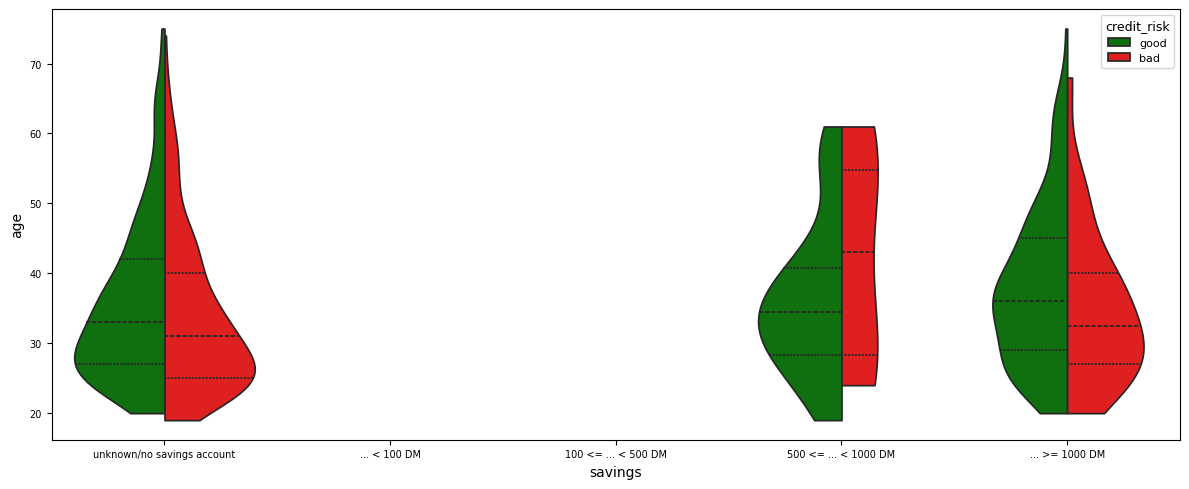

In [10]:
# ваш код здесь

url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

# Define the ordered list of savings categories
order_savings = [
    'unknown/no savings account',
    '... < 100 DM',
    '100 <= ... < 500 DM',
    '500 <= ... < 1000 DM',
    '... >= 1000 DM'
]


df['savings'] = pd.Categorical(df['savings'], categories=order_savings, ordered=True)


savings_counts = df.groupby(['savings', 'credit_risk']).size().unstack(fill_value=0)
print(savings_counts)


missing_categories = set(order_savings) - set(savings_counts.index)
if missing_categories:
    print(f"Warning: Missing savings categories in the data: {missing_categories}")


fig, ax = plt.subplots(figsize=(12, 5))


sns.violinplot(
    data=df,
    x='savings',
    y='age',
    hue='credit_risk',
    order=order_savings,
    palette={'good': 'green', 'bad': 'red'},
    split=True,
    inner='quartile',
    density_norm='area',
    cut=0,
    ax=ax
)


ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('age')


ax.legend(title='credit_risk', title_fontsize=9, fontsize=8, loc='upper right')


plt.tight_layout()
plt.show()

In [11]:
# то что должно получиться

### Задание 5  (0.5 балла)

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

credit_risk
good    700
bad     300
Name: count, dtype: int64
Bins: range(15, 81, 5)


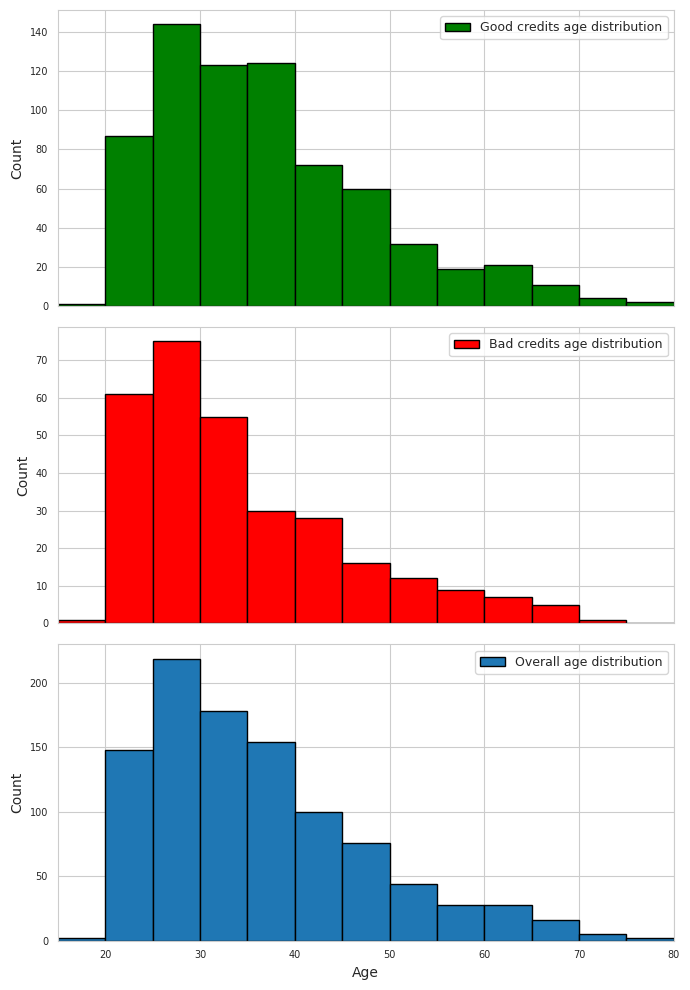

In [12]:
# ваш код здесь

url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)


df = df.dropna(subset=['age'])


print(df['credit_risk'].value_counts())


ages_good = df.loc[df['credit_risk'] == 'good', 'age']
ages_bad = df.loc[df['credit_risk'] == 'bad', 'age']
ages_all = df['age']


bins = range(15, 81, 5)
print(f"Bins: {bins}")


sns.set_style('whitegrid')


fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=True)


axes[0].hist(ages_good, bins=bins, color='green', edgecolor='black', alpha=1.0, label='Good credits age distribution', stacked=False)
axes[0].set_ylabel('Count')
axes[0].legend(loc='upper right', fontsize=9)


axes[1].hist(ages_bad, bins=bins, color='red', edgecolor='black', alpha=1.0, label='Bad credits age distribution', stacked=False)
axes[1].set_ylabel('Count')
axes[1].legend(loc='upper right', fontsize=9)


axes[2].hist(ages_all, bins=bins, color='tab:blue', edgecolor='black', alpha=1.0, label='Overall age distribution', stacked=False)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].legend(loc='upper right', fontsize=9)


axes[2].set_xlim(15, 80)


plt.tight_layout()


plt.show()

In [13]:
# то что должно получиться

### Задание 6  (0.5 балла)

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

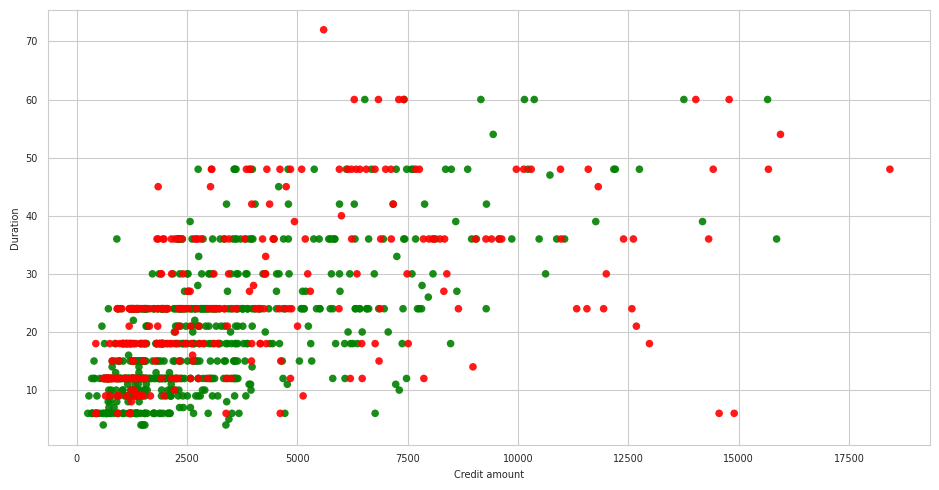

In [14]:
# ваш код здесь

url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

# Переименовываем столбец 'creditAmount' в 'amount', чтобы привести к единому стилю.
df.rename(columns={'creditAmount': 'amount'}, inplace=True)

#Переименовываем столбец 'risk' в 'credit_risk'. Вот теперь все названия столбцов согласованы.
df.rename(columns={'risk': 'credit_risk'}, inplace=True)

# Удаляем строки, содержащие пропущенные значения в столбцах 'amount', 'duration' и 'credit_risk'.
# Это гарантирует, что у нас будут полные данные для графика.
df = df.dropna(subset=['amount', 'duration', 'credit_risk'])


fig, ax = plt.subplots(figsize=(9.5, 5))


good_credits = df[df['credit_risk'] == 'good']
bad_credits = df[df['credit_risk'] == 'bad']


ax.scatter(good_credits['amount'], good_credits['duration'], color='green', marker='o', s=30, alpha=0.9, edgecolors='none', label='good')


ax.scatter(bad_credits['amount'], bad_credits['duration'], color='red', marker='o', s=30, alpha=0.9, edgecolors='none', label='bad')

# Настраиваем оси, заголовок и легенду.
ax.set_xlabel('Credit amount', fontsize=7)
ax.set_ylabel('Duration',fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
sns.set_style("white")

# Настраиваем пределы осей. Добавляем отступы, чтобы точки не касались краёв графика
x_margin = (df['amount'].max() - df['amount'].min()) * 0.05
y_margin = (df['duration'].max() - df['duration'].min()) * 0.05

ax.set_xlim(df['amount'].min() - x_margin, df['amount'].max() + x_margin)
ax.set_ylim(df['duration'].min() - y_margin, df['duration'].max() + y_margin)

# Автоматически корректируем расположение элементов, чтобы всё поместилось на графике
plt.tight_layout()


plt.show()


In [55]:
# то что должно получиться

### Задание 7  (0.5 балла)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

In [16]:
# ваш код здесь
from mpl_toolkits.mplot3d import Axes3D

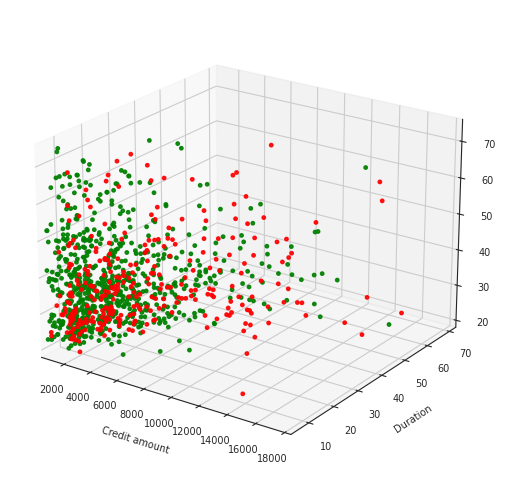

In [17]:

url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

df = df.dropna(subset=['amount', 'duration', 'age', 'credit_risk'])
good = df[df['credit_risk'] == 'good']
bad  = df[df['credit_risk'] == 'bad']

fig = plt.figure(figsize=(5.5, 5))
ax = fig.add_subplot(projection='3d')
ax.scatter(good['amount'], good['duration'], good['age'],
           c='green', s=6, alpha=0.9, label='good')
ax.scatter(bad['amount'],  bad['duration'],  bad['age'],
           c='red',   s=6, alpha=0.9, label='bad')

ax.set_xlabel('Credit amount', fontsize=7)
ax.set_ylabel('Duration', fontsize=7)
ax.set_zlabel('Age', fontsize=7)

ax.set_xlim(df['amount'].min()-1, df['amount'].max()+1)
ax.set_ylim(df['duration'].min()-1, df['duration'].max()+1)
ax.set_zlim(df['age'].min()-1, df['age'].max()+1)

ax.view_init(elev=22, azim=125)
ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.tick_params(axis='z', labelsize=7)

ax.invert_xaxis()
ax.invert_yaxis()

#ax.legend(loc='upper left', fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# то что должно получиться

Что вы можете сказать о сравнении 3D- и 2D-визуализаций? Какие вы видите в них преимущества и недостатки?

Какие выводы с точки зрения бизнеса можно сделать из полученного графика?

**ВАШ ОТВЕТ**  
...

## Раздел 2. Визуализации в датасете Netflix

В данном разделе вы продолжите практиковаться в визуализациях и поработаете с более сложными графиками и инструментами.

Все технические рекомендации остаются неизменными с прошлого раздела.

In [19]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'

### Задание 1  (0.5 балла)

Прочитайте средствами pandas файл с данными Netflix. Посчитайте количество пропусков (NaN) в колонке `director`. Постройте столбчатую диаграмму, которая показывает 5 стран, в которых наибольшее количество фильмов содержат пропуски в столбце `director`.

Добавьте на диаграмму:

- Заголовок жирным шрифтом
- Подписи осей

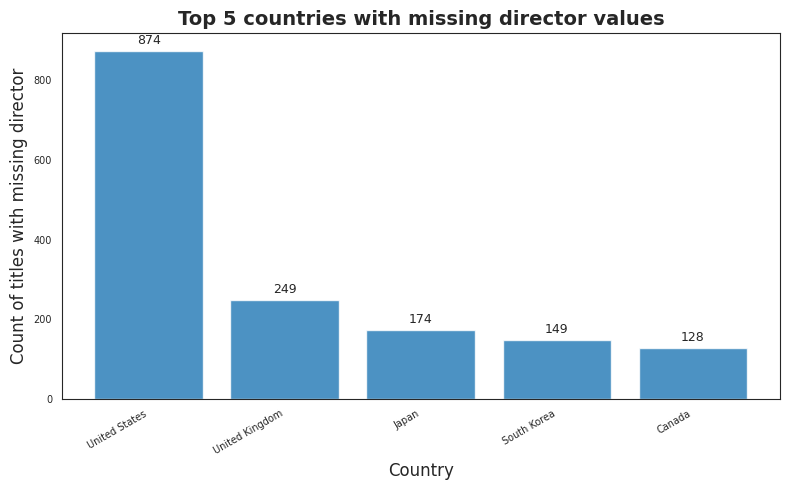

In [52]:
# ваш код здесь

df = pd.read_csv(NETFLIX_TITLES)

# Сначала оставим только строки, где director == NaN
missing_dir = df[df['director'].isna()].copy()

# Если есть пропуски в 'country', отбросим их (они не дают страны) или можно пометить как 'Unknown'
# Здесь отбросим пустые страны
missing_dir = missing_dir[missing_dir['country'].notna()]

# Разделим множественные страны (через запятую)
# Удаляем пробелы вокруг названий стран
missing_dir['country'] = missing_dir['country'].str.split(',')

# explode даст по одной стране на строку
missing_by_country = missing_dir.explode('country')
missing_by_country['country'] = missing_by_country['country'].str.strip()

# Теперь считаем количество пропусков director по странам
counts = missing_by_country['country'].value_counts()

# Берём топ-5 стран
top5 = counts.head(5)

# Построение столбчатой диаграммы
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(top5.index, top5.values, color='tab:blue', alpha=0.8)

# Добавим подписи значений над столбцами (опционально)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(top5.values)*0.01, int(h),
            ha='center', va='bottom', fontsize=9)

# Заголовок жирным шрифтом
ax.set_title('Top 5 countries with missing director values', fontsize=14, fontweight='bold')

# Подписи осей
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Count of titles with missing director', fontsize=12)

# Немного форматирования оси X (чтобы метки не накладывались)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

### Задание 2 (0.5 балла)

Постройте pie chart (круговую диаграмму), показывающую 5 стран, в которых произвели больше всего фильмов.

Добавьте на диаграмму:

+ Заголовок (Тип шрифта: ``family = 'monospace'``, насыщенность: ``fontweight='bold'``)
+ Название стран (Тип шрифта: ``family = 'monospace'``)
+ Подписи значений (%) (Тип шрифта: ``family = 'monospace'``)
+ Выберите стиль для диаграммы pastel c помощью библиотеки ``seaborn``

```colors = sns.color_palette('pastel')[0:5]```

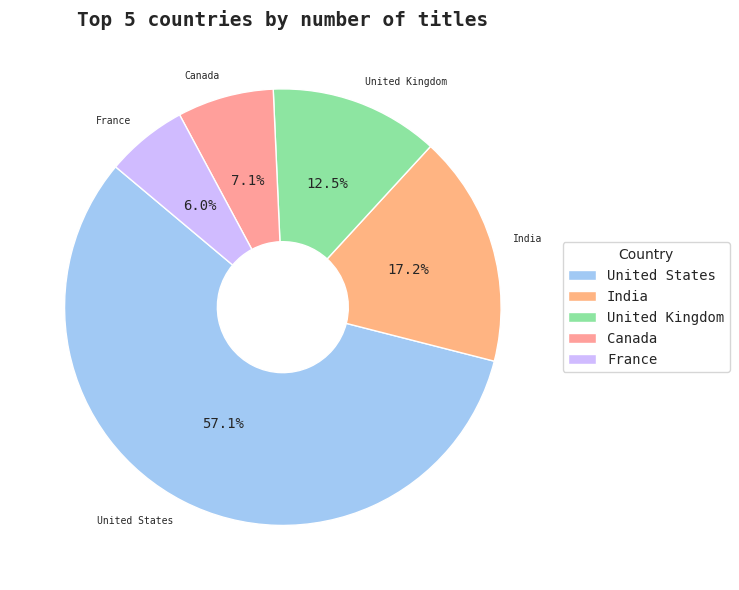

In [21]:
# ваш код здесь

df = pd.read_csv(NETFLIX_TITLES)

# Подготовка: отбросим строки без country или отметим их как 'Unknown' по желанию
df = df[df['country'].notna()].copy()

# В столбце country часто несколько стран, разделённых запятыми.
# Разделим и "взорвём" строки, чтобы считать вклады каждой страны отдельно.
df['country'] = df['country'].str.split(',')
df = df.explode('country')
df['country'] = df['country'].str.strip()

# Считаем количество фильмов по странам
country_counts = df['country'].value_counts()

# Берём топ-5 стран
top5 = country_counts.head(5)
labels = top5.index.tolist()
sizes = top5.values

# Выбираем стиль pastel через seaborn и палитру
sns.set_style('whitegrid')  # нейтральный фон; можно выбрать 'white' или другой
colors = sns.color_palette('pastel')[0:5]

# Рисуем pie chart
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,           # подписи стран (мы их отрисуем через texts, но передаём сюда для соответствия)
    autopct='%1.1f%%',       # подписи значений в процентах
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.7, edgecolor='w')  # width = 1.0 для полного круга
)

# Настройки шрифтов (monospace + жирный заголовок)
for t in texts:
    t.set_fontfamily('monospace')

for at in autotexts:
    at.set_fontfamily('monospace')
    at.set_fontsize(10)

ax.set_title('Top 5 countries by number of titles', fontfamily='monospace', fontweight='bold', fontsize=14)

# Дополнительные настройки размещения легенды/подписей
# Если подписи накладываются, можно сделать легенду справа:
ax.legend(wedges, labels, title='Country', loc='center left', bbox_to_anchor=(1, 0, 0.3, 1), prop={'family': 'monospace'})

plt.tight_layout()
plt.show()

### Задание 3 (1 балл)

Постройте subplots, где на первом графике будет круговая диаграмма, показывающая долю фильмов каждого рейтинга *(rating)*, а на втором столбчатая диаграмма, показывающая 3 страны, в которых было снято больше всего фильмов с рейтингом TV-MA.

*Если фильмов в каких-то рейтингах меньше 50, то их в график брать не нужно.*

Добавьте на диаграммы:

+ Заголовки (можно жирным)

Круговая диаграмма:
+ Подписи значений абсолютные

Столбчатая диаграммма:
+ Сделайте так, чтобы ось Y была справа
+ Добавьте подпись «Количество фильмов» к оси Y и уберите подпись к оси X
+ Оставьте видимыми только правую и нижнюю границы

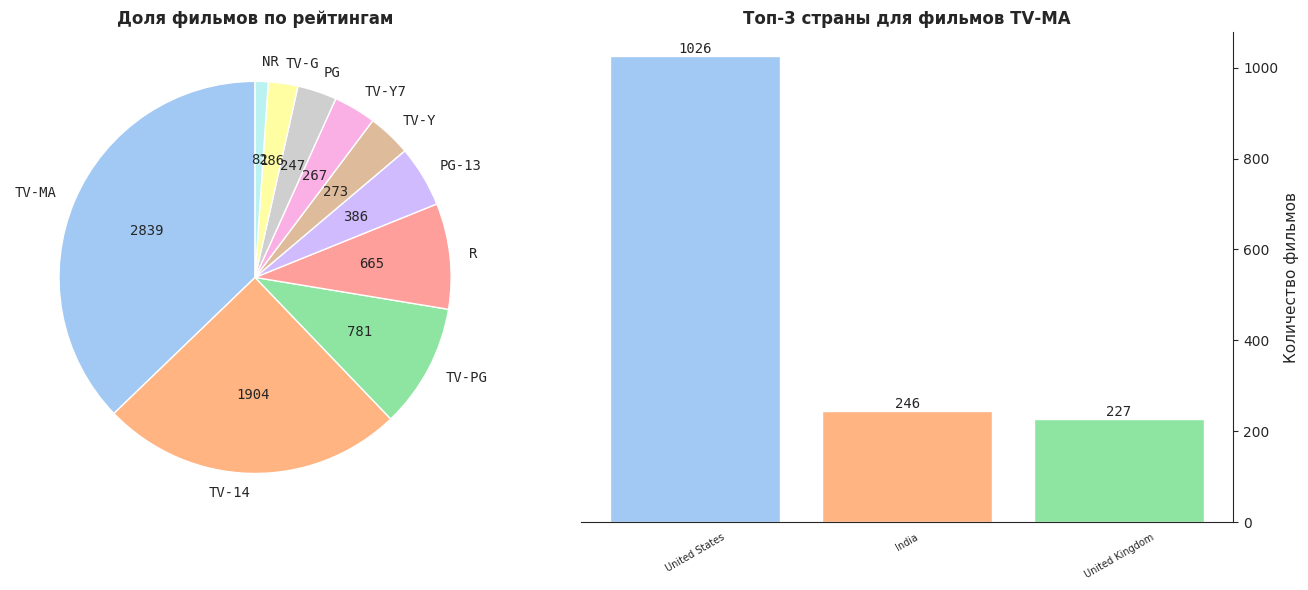

In [50]:
# ваш код здесь
# Убираем строки без rating
ratings_df = df.dropna(subset=['rating']).copy()

# Считаем количества по rating
rating_counts = ratings_df['rating'].value_counts()

# Оставляем только рейтинги с >= 50 фильмов
rating_counts_filtered = rating_counts[rating_counts >= 50]

tv_ma = df[df['rating'] == 'TV-MA'].copy()
tv_ma = tv_ma.dropna(subset=['country'])  # отсекать строки без country

# Разделим множественные страны
tv_ma['country'] = tv_ma['country'].str.split(',')
tv_ma_exploded = tv_ma.explode('country')
tv_ma_exploded['country'] = tv_ma_exploded['country'].str.strip()

# Считаем по странам и берём топ-3
tv_ma_country_counts = tv_ma_exploded['country'].value_counts()
top3_tv_ma = tv_ma_country_counts.head(3)

sns.set_style('white')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax0 = axes[0]
ax0.set_title('Доля фильмов по рейтингам', fontweight='bold')

# Функция для отображения абсолютных значений в autopct
def absolute_value(pct):
    total = rating_counts_filtered.sum()
    val = int(round(pct * total / 100.0))
    return f"{val}"

# Цвета (можно использовать pastel палитру)
colors_pie = sns.color_palette('pastel', n_colors=len(rating_counts_filtered))

wedges, texts, autotexts = ax0.pie(
    rating_counts_filtered.values,
    labels=rating_counts_filtered.index,
    autopct=absolute_value,
    startangle=90,
    colors=colors_pie,
    textprops={'family': 'sans-serif'}  # подписи рейтингов
)

# Настроим шрифты для подписи значений (autotexts)
for at in autotexts:
    at.set_fontfamily('monospace')
    at.set_fontsize(10)

for t in texts:
    t.set_fontfamily('monospace')
    t.set_fontsize(10)

# ---------- Bar (правый) ----------
ax1 = axes[1]
ax1.set_title('Топ-3 страны для фильмов TV‑MA', fontweight='bold')

colors_bar = sns.color_palette('pastel')[0:3]
bars = ax1.bar(top3_tv_ma.index, top3_tv_ma.values, color=colors_bar)

# Подписи над столбцами (абсолютные значения)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h, f'{int(h)}', ha='center', va='bottom', fontsize=10, family='monospace')

# Ось Y справа
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position('right')
ax1.set_ylabel('Количество фильмов', fontsize=11)

ax1.set_xlabel('')

# Оставить видимыми только правую и нижнюю границы
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax1.spines['bottom'].set_visible(True)

# Немного оформить оси и метки
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

### Задание 4 (1 балл)

Преобразуйте колонку `date_added` в datetime. Создайте новые столбцы month и year из преобразованного столбца. Постройте линейный график: сколько в среднем фильмов было снято в каждый из месяцев.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Маркеры на точках перегиба
+ Настройте ось X: ось начинается с 1 заканчивается 12, шаг 1

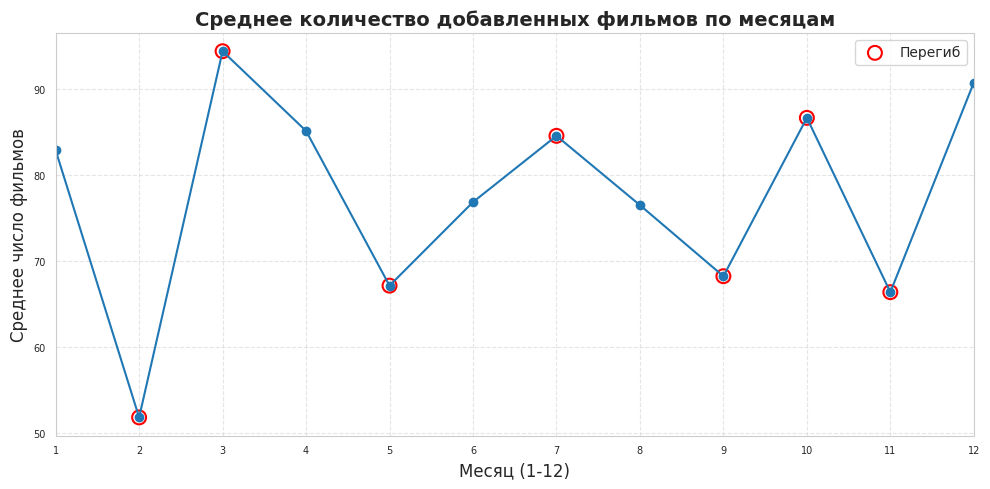

In [49]:

# Преобразование date_added в datetime
# Некоторые записи могут иметь NaN — оставим их, но при создании month/year отбросим NaT
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['month'] = df['date_added'].dt.month
df['year'] = df['date_added'].dt.year

# Уберём записи без date_added (если нужно)
df_with_date = df.dropna(subset=['date_added']).copy()

# Подсчёт: сколько фильмов было добавлено в каждом месяце по годам,
# затем берём среднее по годам: mean number of titles per month.
# Сначала сгруппируем по year и month и посчитаем количество записей в каждой паре
monthly_counts_by_year = df_with_date.groupby(['year', 'month']).size().reset_index(name='count')

# Теперь для каждого месяца вычислим среднее по годам
avg_per_month = monthly_counts_by_year.groupby('month')['count'].mean().reindex(range(1,13))


avg_per_month = avg_per_month.fillna(0)
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(avg_per_month.index, avg_per_month.values, marker='o', linestyle='-', color='tab:blue')

# Находим точки перегиба (local maxima/minima) и ставим особые маркеры
# Здесь определим перегибы как локальные экстремумы: сравнивая соседей
y = avg_per_month.values
x = np.array(avg_per_month.index)

# Для крайних точек не рассматриваем как перегибы; проверим внутренние точки
peaks_idx = []
for i in range(1, len(y)-1):
    if (y[i] > y[i-1] and y[i] > y[i+1]) or (y[i] < y[i-1] and y[i] < y[i+1]):
        peaks_idx.append(i)

# Наносим маркеры на точки перегиба
if peaks_idx:
    ax.scatter(x[peaks_idx], y[peaks_idx], s=100, facecolors='none', edgecolors='red', linewidths=1.5, label='Перегиб')

# Подписи и оформление
ax.set_title('Среднее количество добавленных фильмов по месяцам', fontsize=14, fontweight='bold')
ax.set_xlabel('Месяц (1-12)', fontsize=12)
ax.set_ylabel('Среднее число фильмов', fontsize=12)

# Настроим ось X: от 1 до 12 шаг 1
ax.set_xlim(1, 12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([str(m) for m in range(1,13)])

# Показать сетку и легенду (если есть)
ax.grid(True, linestyle='--', alpha=0.5)
if peaks_idx:
    ax.legend()

plt.tight_layout()
plt.show()

### Задание 5 (1 балл)

Постройте линейный график, в какие годы (столбец year, который вы создали в задании 4) сколько фильмов было снято.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Измените цвет линии графика и сделайте ее пунктиром
+ Решетку на фон

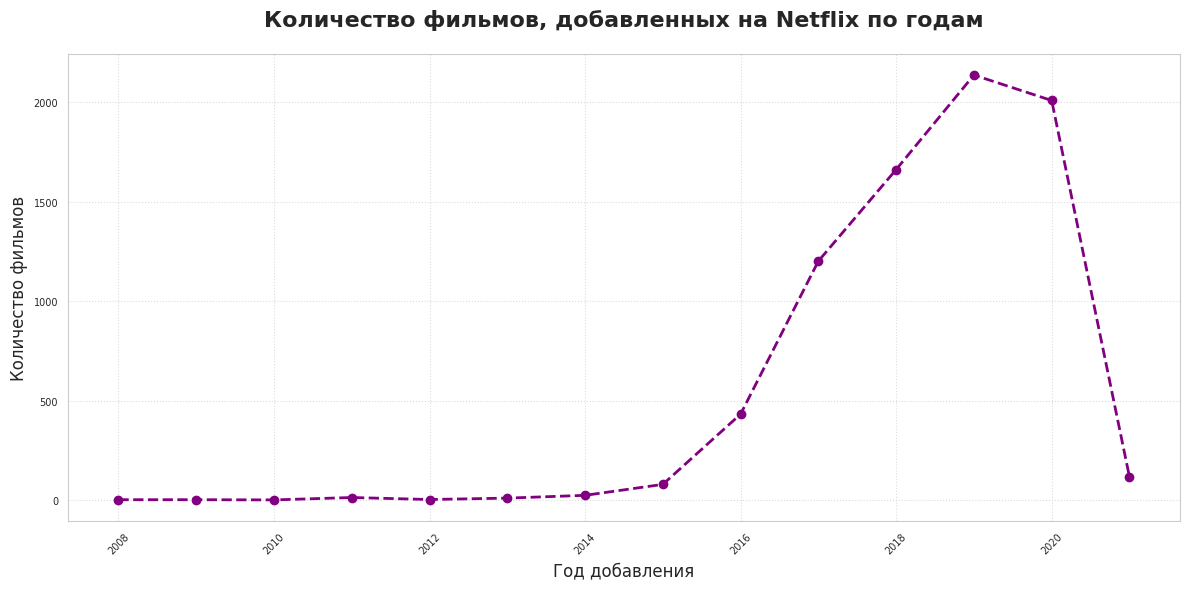

In [48]:
# ваш код здесь


# Преобразование колонки 'date_added' в datetime
# 'errors='coerce' преобразует невалидные даты в NaT (Not a Time)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Создание нового столбца 'year_added' из преобразованного столбца
# Это соответствует 'year' из задания 4, если речь идет о годе добавления.
df['year_added'] = df['date_added'].dt.year

# Убираем строки, где 'year_added' является NaN (то есть 'date_added' был невалидным)
df_valid_years = df.dropna(subset=['year_added']).copy()

films_per_year = df_valid_years['year_added'].astype(int).value_counts().sort_index()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(films_per_year.index,          # Годы по оси X
        films_per_year.values,         # Количество фильмов по оси Y
        color='purple',                # Цвет линии - фиолетовый
        linestyle='--',                # Стиль линии - пунктир
        marker='o',                    # Маркеры на каждой точке данных
        linewidth=2)                   # Толщина линии

ax.set_title('Количество фильмов, добавленных на Netflix по годам',
             fontsize=16,
             fontweight='bold',
             pad=20)

# Подписи осей
ax.set_xlabel('Год добавления', fontsize=12)
ax.set_ylabel('Количество фильмов', fontsize=12)

ax.tick_params(axis='x', rotation=45) # Поворот меток по оси X для предотвращения наложений

ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Задание 6 (1 балл)

Будем работать со столбцом duration. Одни данные даны в минутах (для фильмов (Movie)), а другие в сезонах (для сериалов (TV shows)). Создайте два новых столбца min (для тех, у кого продолжительность в минутах) и season (для тех, у кого продолжительность в сезонах), в которых будут извлечены данные из столбца duration.

Постройте subplots, где на первом графике гистрограмма распределения продолжительности фильмов, а на втором – гистрограмма распределения продолжительности сериалов.

Добавьте на графики:

+ Заголовки жирным шрифтом
+ Подписи осей

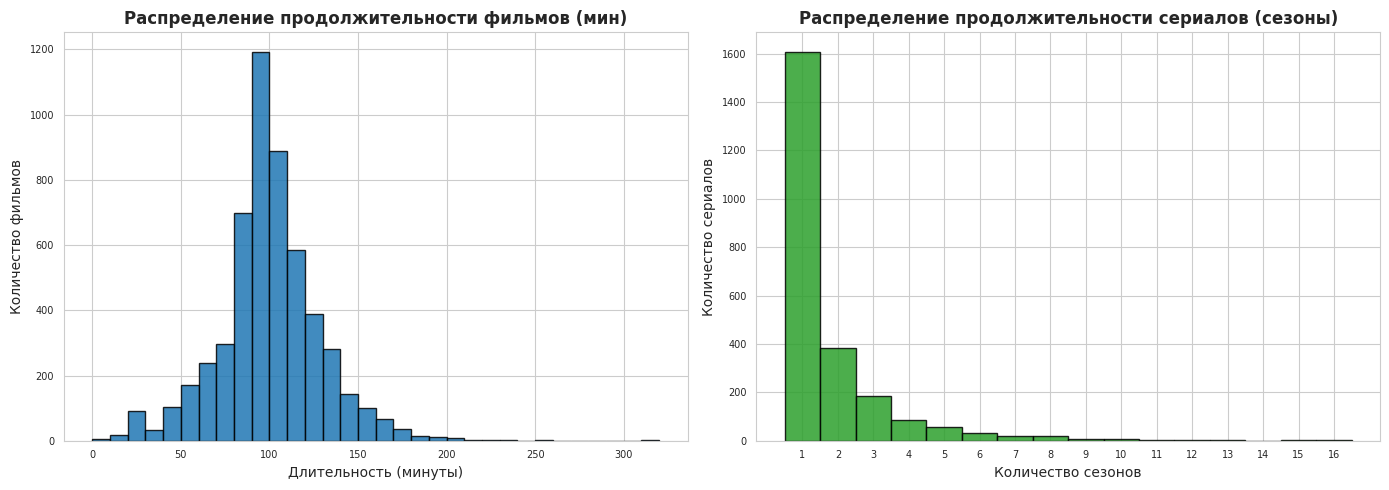

In [30]:
# ваш код здесь

def parse_duration_simple(s):
    if pd.isna(s):
        return np.nan, np.nan
    s = str(s).strip()
    parts = s.split()           # ожидаем формат вида ["90","min"] или ["3","Seasons"]
    if not parts:
        return np.nan, np.nan
    num = parts[0]
    try:
        value = int(num)
    except:
        return np.nan, np.nan
    unit = parts[1].lower() if len(parts) > 1 else ''
    if 'min' in unit:           # минуты
        return value, np.nan
    if 'season' in unit:        # сезон/сезоны
        return np.nan, value
    # на всякий случай: по умолчанию считаем, что это минуты
    return value, np.nan

mins, seasons = zip(*df['duration'].apply(parse_duration_simple))
df['min'] = pd.to_numeric(mins, errors='coerce')
df['season'] = pd.to_numeric(seasons, errors='coerce')

# Подготовка данных для гистограмм
movies_min = df[(df['type'].str.lower() == 'movie') & df['min'].notna()]['min'].astype(int)
tv_seasons = df[(df['type'].str.lower() == 'tv show') & df['season'].notna()]['season'].astype(int)


sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax0 = axes[0]
bins_movies = np.arange(0, (movies_min.max() // 10 + 2) * 10, 10) if len(movies_min) else np.arange(0, 181, 10)
ax0.hist(movies_min, bins=bins_movies, color='tab:blue', edgecolor='black', alpha=0.85)
ax0.set_title('Распределение продолжительности фильмов (мин)', fontweight='bold')
ax0.set_xlabel('Длительность (минуты)')
ax0.set_ylabel('Количество фильмов')

ax1 = axes[1]
if len(tv_seasons):
    max_se = int(tv_seasons.max())
    bins_seasons = np.arange(0.5, max_se + 1.5, 1)
    xticks = range(1, max_se + 1)
else:
    bins_seasons = np.arange(0.5, 6.5, 1)
    xticks = range(1, 6)
ax1.hist(tv_seasons, bins=bins_seasons, color='tab:green', edgecolor='black', alpha=0.85)
ax1.set_title('Распределение продолжительности сериалов (сезоны)', fontweight='bold')
ax1.set_xlabel('Количество сезонов')
ax1.set_ylabel('Количество сериалов')
ax1.set_xticks(xticks)

plt.tight_layout()
plt.show()

### Задание 7 (0.5 балла)

Постройте ящик с усами (box plot) по продолжительности фильмов (Movies). Визуально проинтерпретируйте его.

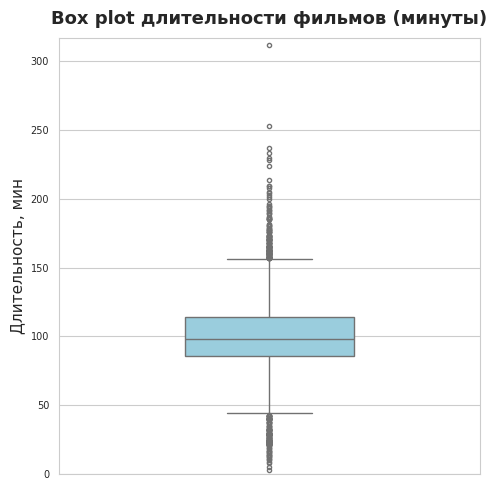

In [33]:
# ваш код здесь

def parse_minutes(s):
    if pd.isna(s):
        return np.nan
    parts = str(s).strip().split()
    if len(parts) < 2:
        return np.nan
    try:
        v = int(parts[0])
    except:
        return np.nan
    return v if 'min' in parts[1].lower() else np.nan

df['min'] = df['duration'].apply(parse_minutes)
movies = df[(df['type'].str.lower() == 'movie') & df['min'].notna()].copy()

sns.set_style('whitegrid')
plt.figure(figsize=(5, 5))

sns.boxplot(
    y=movies['min'],          # вертикально: используем ось Y
    color='#8fd3e8',
    width=0.4,
    fliersize=3,
    linewidth=1
)

plt.title('Box plot длительности фильмов (минуты)', fontweight='bold', fontsize=13, pad=10)
plt.ylabel('Длительность, мин', fontsize=11)
plt.xlabel('')

# Чуть расширим диапазон Y, чтобы уместить выбросы
ymin = max(0, movies['min'].min() - 5)
ymax = movies['min'].max() + 5
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

### Задание 8* (1 балл)

Постройте при помощи библиотеки plotly интерактивную столбчатую диаграмму, которая сравнивает среднюю продолжительность фильмов и сериалов за каждый год, начиная с 2000.

In [43]:
# ваш код здесь
import plotly.express as px
import plotly.graph_objects as go

In [47]:
def parse_duration_simple(s):
    if pd.isna(s):
        return np.nan, np.nan
    s = str(s).strip()
    parts = s.split()
    if not parts or not parts[0].lstrip('-').isdigit():
        return np.nan, np.nan
    num = int(parts[0])
    unit = parts[1].lower() if len(parts) > 1 else ''
    if 'min' in unit:
        return num, np.nan
    if 'season' in unit:
        return np.nan, num
    return np.nan, np.nan

df[['duration_min', 'duration_season']] = df['duration'].apply(lambda x: pd.Series(parse_duration_simple(x)))

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

df = df[df['year_added'] >= 2000].copy()

#средняя длительность в минутах по годам
movie_grp = (
    df[df['type'].str.lower() == 'movie']
      .groupby('year_added', as_index=True)['duration_min']
      .mean()
      .rename('avg_movie_min')
)

#среднее количество сезонов по годам
tv_grp = (
    df[df['type'].str.lower() == 'tv show']
      .groupby('year_added', as_index=True)['duration_season']
      .mean()
      .rename('avg_tv_seasons')
)

merged = pd.concat([movie_grp, tv_grp], axis=1).sort_index()

# Для гарантии, берем только годы, где хоть одна метрика есть
merged = merged.dropna(how='all')

# Построение
fig = go.Figure(data=[
    go.Bar(name='Фильмы (средняя длительность, мин)', x=merged.index.astype(str), y=merged['avg_movie_min'], marker_color='skyblue'),
    go.Bar(name='Сериалы (среднее кол-во сезонов)', x=merged.index.astype(str), y=merged['avg_tv_seasons'], marker_color='lightcoral')
])

fig.update_layout(
    barmode='group',
    title_text='<b>Средняя длительность фильмов и кол-во сезонов по годам (с 2000)</b>',
    xaxis_title='Год',
    yaxis_title='Среднее значение',
    xaxis_tickangle=-45,
    hovermode='x unified'
)

fig.show()